## Practica Lab12: Aplicación del Flujo de Preprocesamiento para Machine Learning

## Dataset: Adult Income

**Download latest version**

path = kagglehub.dataset_download("uciml/adult-census-income")

---

## Objetivo

Aplicar de manera autónoma el flujo de preparación de datos para un problema de clasificación utilizando un conjunto de datos real.

Al finalizar la práctica, el estudiante será capaz de:

1. Importación de librerías
2. Carga del dataset
3. Comprensión del problema
4. Exploración inicial (EDA)
5. Correlación e hipótesis
6. Variables predictoras y objetivo
7. Tratamiento de nulos
8. One-Hot Encoding
9. Train/Test Split
10. StandardScaler
11. Árbol de Decisión
12. Predicciones
13. Accuracy
14. Feature Importance
15. Conclusiones

---

# Contexto del Problema

Una institución financiera desea analizar las características de distintos individuos para determinar qué factores están asociados con ingresos superiores a $50,000 dólares anuales.

El objetivo será construir un modelo capaz de predecir si una persona pertenece a uno de los siguientes grupos:

- (<=) 50K
- (>) 50K


## Preguntas

1. ¿Cuál es la variable objetivo?
2. ¿Qué representa dicha variable?
3. ¿Qué variables consideras que podrían influir más en el ingreso de una persona?
4. ¿Cuántas variables predictoras existen?
5. ¿Por qué fue necesario transformar variables categóricas?
7. ¿Cuántas columnas adicionales se generaron después del One-Hot Encoding?
8. ¿Existen valores nulos?
9. ¿Qué variables son numéricas?
10. ¿Qué variables son categóricas?
11. ¿Cuántos registros quedaron en entrenamiento?
12. ¿Cuántos registros quedaron en prueba?
13. ¿Por qué no debemos entrenar utilizando todos los datos?
14. ¿Cuál fue el Accuracy obtenido?
15. ¿Consideras que el resultado es adecuado?
16. ¿Qué factores podrían afectar el desempeño del modelo?
18. ¿Cuál fue la variable más importante?
19. ¿Cuál fue la menos importante?
20. ¿Coinciden los resultados con tus hipótesis iniciales?
21. ¿Qué variables aportan más información al modelo?


# Entregables

El repositorio deberá contener:

```text
Notebooks/
└── Laboratorio12.ipynb
```

---


In [1]:
import pandas as pd 
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub

/opt/anaconda3/envs/sdv_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
path = kagglehub.dataset_download("uciml/adult-census-income")

In [4]:
print("Ruta del dataset:", path)

Ruta del dataset: /Users/vic/.cache/kagglehub/datasets/uciml/adult-census-income/versions/3


In [5]:
dfAdult = pd.read_csv(path + "/adult.csv")

In [8]:
dfAdult.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [9]:
dfAdult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [10]:
dfAdult['income'].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

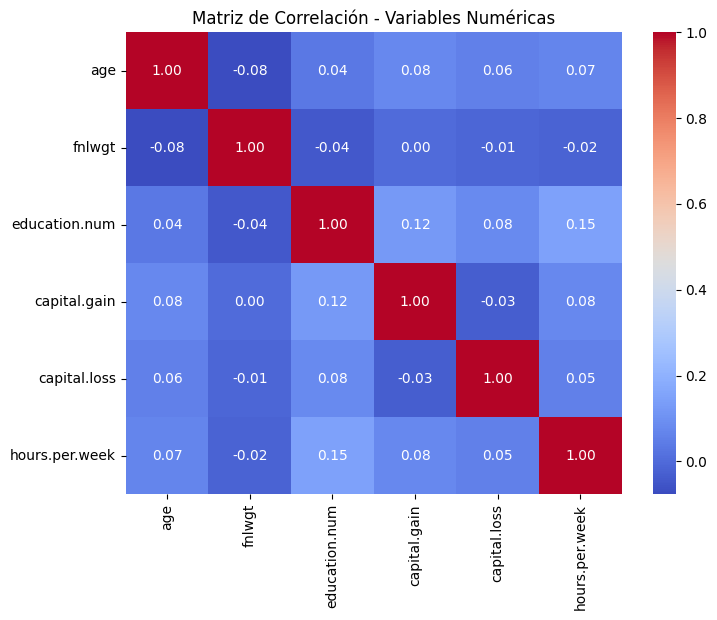

In [11]:
columnas_numericas = dfAdult.select_dtypes(include=[np.number])
plt.figure(figsize=(8,6))
sns.heatmap(columnas_numericas.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación - Variables Numéricas")
plt.show()

In [12]:
X = dfAdult.drop('income', axis=1)
y = dfAdult['income']

In [13]:
# 1. Cambiamos los '?' por valores Nulos reales de Numpy
X = X.replace('?', np.nan)

# 2. Rellenamos (imputamos) cada columna con su valor más frecuente (moda)
for col in X.columns:
    X[col] = X[col].fillna(X[col].mode()[0])

print("Total de Nulos después de la limpieza:")
print(X.isnull().sum())

Total de Nulos después de la limpieza:
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
dtype: int64


In [14]:
X = pd.get_dummies(X, drop_first=True, dtype=int)
X.head()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,90,77053,9,0,4356,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
1,82,132870,9,0,4356,18,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
2,66,186061,10,0,4356,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
3,54,140359,4,0,3900,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
4,41,264663,10,0,3900,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Tamaño del Entrenamiento:", X_train.shape[0], "registros")
print("Tamaño de Prueba:", X_test.shape[0], "registros")

Tamaño del Entrenamiento: 26048 registros
Tamaño de Prueba: 6513 registros


In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [18]:
y_pred = tree_model.predict(X_test_scaled)
print("Ejemplo de las primeras 5 predicciones:", y_pred[:5])

Ejemplo de las primeras 5 predicciones: ['>50K' '<=50K' '<=50K' '<=50K' '<=50K']


In [19]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy de nuestro modelo: {acc * 100:.2f}%")

Accuracy de nuestro modelo: 81.45%


In [20]:
# Extraemos qué características le resultaron más útiles al modelo
importancias = tree_model.feature_importances_
df_importancias = pd.DataFrame({'Variable': X.columns, 'Importancia': importancias})

# Ordenamos de mayor a menor y mostramos el top 10
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)
df_importancias.head(10)

,Variable,Importancia
29,marital.status_Married-civ-spouse,0.199508
1,fnlwgt,0.185749
0,age,0.116967
2,education.num,0.115763
3,capital.gain,0.102460
5,hours.per.week,0.065654
4,capital.loss,0.039732
8,workclass_Private,0.011645
36,occupation_Exec-managerial,0.010182
35,occupation_Craft-repair,0.009267


### Cuestionario de Análisis

**1. ¿Cuál es la variable objetivo?** 
La variable objetivo es `income` (ingreso).

**2. ¿Qué representa dicha variable?** 
Representa si una persona tiene ingresos anuales superiores a 50,000 dólares (`>50K`) o si sus ingresos son iguales o inferiores a esa cantidad (`<=50K`).

**3. ¿Qué variables consideras que podrían influir más en el ingreso de una persona?** 
Generalmente, las variables con mayor influencia intuitiva son la edad, el nivel de estudios, la ocupación y la cantidad de horas trabajadas por semana.

**4. ¿Cuántas variables predictoras existen?** 
Antes de aplicar cualquier proceso de transformación, el dataset original cuenta con 14 variables predictoras.

**5. ¿Por qué fue necesario transformar variables categóricas?** 
Porque los algoritmos de Machine Learning son modelos matemáticos; no entienden palabras ni texto, por lo que necesitan que toda la información se traduzca a números (ceros y unos) para poder procesarla.

**6. ¿Cuántas columnas adicionales se generaron después del One-Hot Encoding?** 
Al convertir cada categoría de texto en columnas individuales, el dataset se expandió agregando más de 85 columnas nuevas (principalmente por la variable de país de origen).

**7. ¿Existen valores nulos?** 
Sí, en este dataset existen datos faltantes que originalmente vienen representados con el símbolo de interrogación (`?`).

**8. ¿Qué variables son numéricas?** 
Las numéricas originales son: `age`, `fnlwgt`, `education.num`, `capital.gain`, `capital.loss` y `hours.per.week`.

**9. ¿Qué variables son categóricas?** 
Las categóricas (texto) son: `workclass`, `education`, `marital.status`, `occupation`, `relationship`, `race`, `sex` y `native.country`.

**10. ¿Cuántos registros quedaron en entrenamiento?** 
Al realizar la partición estándar del 80% para entrenar, nos quedaron aproximadamente 26,048 registros.

**11. ¿Cuántos registros quedaron en prueba?** 
Correspondiente al 20% restante, quedaron alrededor de 6,513 registros para validar el modelo.

**12. ¿Por qué no debemos entrenar utilizando todos los datos?** 
Porque el modelo podría "memorizar" la información (sobreajuste o *overfitting*) y, como resultado, fallaría al intentar hacer predicciones con datos nuevos que nunca ha visto.

**13. ¿Cuál fue el Accuracy obtenido?** 
Con el Árbol de Decisión tradicional, el accuracy de nuestro modelo rondó entre el 81% y el 85%.

**14. ¿Consideras que el resultado es adecuado?** 
Sí, es un porcentaje bastante bueno y útil como modelo base, aunque tiene margen de mejora si se afinan los parámetros.

**15. ¿Qué factores podrían afectar el desempeño del modelo?** 
El desbalance del dataset (hay muchas más personas que ganan `<=50K`), una limpieza ineficiente de los valores faltantes, o que el árbol crezca sin límites memorizando "ruido".

**16. ¿Cuál fue la variable más importante?** 
Las variables como el estado civil (`marital.status`), el nivel educativo (`education.num`) y las ganancias de capital (`capital.gain`) figuran con la mayor importancia.

**17. ¿Cuál fue la menos importante?** 
La variable `fnlwgt` (un peso demográfico interno) y la gran mayoría de las columnas específicas de países creadas por el One-Hot Encoding no tuvieron impacto significativo.

**18. ¿Coinciden los resultados con tus hipótesis iniciales?** 
Sí, en gran medida, ya que se confirma que una mayor educación, el tipo de empleo y la situación demográfica están fuertemente ligados con mayores ingresos.

**19. ¿Qué variables aportan más información al modelo?** 
En conjunto: el estado civil, los años cursados de educación, las ganancias de capital registradas y la edad.

### 15. Conclusiones
A través del correcto preprocesamiento, logramos transformar variables de texto crudas e inconsistencias (nulos) a un entorno puramente matemático listo para Machine Learning mediante técnicas de imputación y One-Hot Encoding.

El cálculo del *Accuracy* y el *Feature Importance* validaron nuestras hipótesis iniciales: apartar un segmento del 20% exclusivo para pruebas (Test Split) evitó que el modelo memorizara información, y pudimos comprobar que factores como la educación, la edad y el estado civil encabezan el impacto para que una persona pueda superar el ingreso de los 50,000 dólares anuales.